In [9]:
import kagglehub

path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis"
)

print(path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
/kaggle/input/twitter-entity-sentiment-analysis


In [10]:
import os
print(os.listdir(path))

['twitter_validation.csv', 'twitter_training.csv']


In [11]:
import pandas as pd
df = pd.read_csv(
    os.path.join(path, "twitter_training.csv"),
    header=None
)

df.head()

,0,1,2,3
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [12]:
df.columns

Index([0, 1, 2, 3], dtype='int64')

In [13]:
df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [15]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 74682
Columns : 4


In [16]:
df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,686


In [17]:
df.dropna(inplace=True)

df.isnull().sum()

,0
Tweet_ID,0
Entity,0
Sentiment,0
Tweet,0


In [18]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 2340


In [19]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [20]:
df["Sentiment"].value_counts()

,count
Sentiment,
Negative,21698
Positive,19713
Neutral,17708
Irrelevant,12537


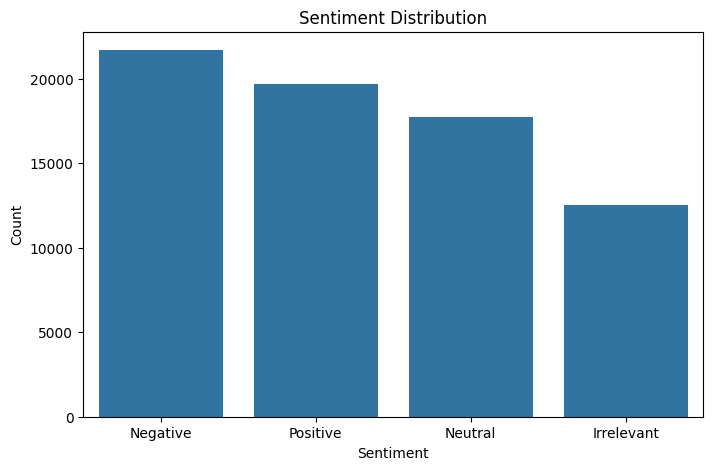

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df,
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

In [22]:
df = df[["Tweet", "Sentiment"]]

df.head()

,Tweet,Sentiment
0,im getting on borderlands and i will murder yo...,Positive
1,I am coming to the borders and I will kill you...,Positive
2,im getting on borderlands and i will kill you ...,Positive
3,im coming on borderlands and i will murder you...,Positive
4,im getting on borderlands 2 and i will murder ...,Positive


In [23]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [24]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

In [25]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\\S+|www\\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\\w+", "", text)

    # Remove hashtags (# but keep the word)
    text = re.sub(r"#", "", text)

    # Remove numbers
    text = re.sub(r"\\d+", "", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove extra spaces
    text = re.sub(r"\\s+", " ", text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

df.head()

In [ ]:
df[['Tweet','Clean_Tweet']].head(10)

In [ ]:
df['Tweet_Length'] = df['Tweet'].astype(str).apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df['Tweet_Length'], bins=30)

plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Clean_Tweet'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Overall Word Cloud")

plt.show()

In [ ]:
positive = " ".join(
    df[df['Sentiment']=="Positive"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets")

plt.show()

In [ ]:
negative = " ".join(
    df[df['Sentiment']=="Negative"]['Clean_Tweet']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative)

plt.figure(figsize=(14,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Tweets")

plt.show()

In [ ]:
from collections import Counter

words = " ".join(df['Clean_Tweet']).split()

common = Counter(words).most_common(20)

common_df = pd.DataFrame(
    common,
    columns=['Word','Frequency']
)

common_df

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_df,
    x='Frequency',
    y='Word'
)

plt.title("Top 20 Trending Words")

plt.show()

In [ ]:
df['Sentiment'] = df['Sentiment'].replace({
    'Negative':0,
    'Neutral':1,
    'Positive':2,
    'Irrelevant':3
})

df.head()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['Clean_Tweet'])

y = df['Sentiment']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [ ]:
print(df.dtypes)

In [ ]:
X = df["Clean_Tweet"]
y = df["Sentiment"]

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy :", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
labels = ['Negative','Neutral','Positive','Irrelevant']

sizes = df['Sentiment'].value_counts().sort_index()

plt.figure(figsize=(8,8))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Public Opinion Distribution")

plt.show()

In [ ]:
def predict_sentiment(comment):

    comment = clean_text(comment)

    vector = tfidf.transform([comment])

    prediction = lr.predict(vector)[0]

    labels = {
        0:'Negative',
        1:'Neutral',
        2:'Positive',
        3:'Irrelevant'
    }

    print("Predicted Sentiment :", labels[prediction])

In [ ]:
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Clean_Tweet"])

lr.fit(X_train, y_train)

In [ ]:
predict_sentiment(
    "This phone is amazing. I love its camera and battery life!"
)

In [ ]:
predict_sentiment(
    "Worst product ever. Completely disappointed."
)